# Sentiment x Prediction Mapping

In [1]:
import os
import sys
import warnings

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)

## Maya's Approach

In [3]:
data_path = os.path.join(base_data_path, "financial_phrase_bank/corrections/", "Merged_byHand.xlsx")
df = pd.read_excel(data_path)
df.rename(columns={'Sentence Label': 'Ground Truth'}, inplace=True)
df

,Sentiment,Base Sentence,maya_label,Ground Truth,Author Type
0,neutral,----------------------------------------------...,NON-PREDICTION,0,1
1,neutral,- Among other Finnish shares traded in the US ...,NON-PREDICTION,0,1
2,positive,- BEIJING XFN-ASIA - Hong Kong-listed Standard...,NON-PREDICTION,0,1
3,neutral,- Cash flow from operating activities before i...,NON-PREDICTION,0,1
4,neutral,- Cash flow from operating activities before i...,NON-PREDICTION,0,1
...,...,...,...,...,...
4841,neutral,"When completed , the 120-meter Watchtower will...",PREDICTION,1,1
4842,positive,"When open next year , it will be the largest f...",PREDICTION,1,1
4843,neutral,"When the negotiations were started , Neste Oil...",PREDICTION,1,1
4844,positive,"When the situation normalises , the company wi...",PREDICTION,1,1


In [4]:
label_column = "Sentiment"

order = ["negative", "neutral", "positive"]

df[label_column] = df[label_column].str.lower()

maya_grouped_df = df.sort_values(
    by=label_column,
    key=lambda x: pd.Categorical(x, categories=order, ordered=True)
)
maya_grouped_df

,Sentiment,Base Sentence,maya_label,Ground Truth,Author Type
1010,negative,EB announced in its stock exchange release on ...,NON-PREDICTION,0,1
638,negative,Asian traffic declined by 3.4 per cent .,NON-PREDICTION,0,1
3217,negative,The company said that its comparable operating...,NON-PREDICTION,0,1
2465,negative,Peer Peugeot fell 0.81 pct as its sales rose o...,NON-PREDICTION,0,1
2467,negative,Performance in 2006 was impacted by the consol...,NON-PREDICTION,0,1
...,...,...,...,...,...
2339,positive,Operating profit improved by 44.0 % to ER 4.7 ...,NON-PREDICTION,0,1
2338,positive,Operating profit improved by 39.9 % to EUR 18....,NON-PREDICTION,0,1
2337,positive,Operating profit improved by 27 % to EUR 579.8...,NON-PREDICTION,0,1
2355,positive,Operating profit rose to EUR 13.5 mn from EUR ...,NON-PREDICTION,0,1


In [5]:
def map_sentiment_to_prediction(df):
    negp = []   # negative sentiment with prediction
    neup = []   # neutral sentiment with prediction
    posp = []   # positive sentiment with prediction

    negnp = []  # negative sentiment with non-prediction
    neunp = []  # neutral sentiment with non-prediction
    posnp = []  # positive sentiment with non-prediction


    for idx, row in df.iterrows():
        sentence = row['Base Sentence']
        sentiment = row['Sentiment']
        gt = row['Ground Truth']

        if pd.isna(gt):
            continue
        else:
            # ----- NEGATIVE -----
            if sentiment == "negative" and gt == 1:
                negp.append({
                    'Base Sentence': sentence,
                    'Sentiment': sentiment,
                    'Prediction Label': gt,
                    'Class': 'Negative + Prediction'
                })

            elif sentiment == "negative" and gt == 0:
                negnp.append({
                    'Base Sentence': sentence,
                    'Sentiment': sentiment,
                    'Prediction Label': gt,
                    'Class': 'Negative + NOT Prediction'
                })

            # ----- NEUTRAL -----
            elif sentiment == "neutral" and gt == 1:
                neup.append({
                    'Base Sentence': sentence,
                    'Sentiment': sentiment,
                    'Prediction Label': gt,
                    'Class': 'Neutral + Prediction'
                })

            elif sentiment == "neutral" and gt == 0:
                neunp.append({
                    'Base Sentence': sentence,
                    'Sentiment': sentiment,
                    'Prediction Label': gt,
                    'Class': 'Neutral + NOT Prediction'
                })

            # ----- POSITIVE -----
            elif sentiment == "positive" and gt == 1:
                posp.append({
                    'Base Sentence': sentence,
                    'Sentiment': sentiment,
                    'Prediction Label': gt,
                    'Class': 'Positive + Prediction'
                })

            elif sentiment == "positive" and gt == 0:
                posnp.append({
                    'Base Sentence': sentence,
                    'Sentiment': sentiment,
                    'Prediction Label': gt,
                    'Class': 'Positive + NOT Prediction'
                })


    # Convert to DataFrames
    negp_df = pd.DataFrame(negp)
    neup_df = pd.DataFrame(neup)
    posp_df = pd.DataFrame(posp)

    negnp_df = pd.DataFrame(negnp)
    neunp_df = pd.DataFrame(neunp)
    posnp_df = pd.DataFrame(posnp)

    # Concatenate
    grouped_df = DataProcessing.concat_dfs([
        negp_df, neup_df, posp_df,
        negnp_df, neunp_df, posnp_df
    ])

    return grouped_df

In [6]:
maya_grouped_df = map_sentiment_to_prediction(maya_grouped_df)
maya_grouped_df

,Base Sentence,Sentiment,Prediction Label,Class
0,Stora Enso Oyj said its second-quarter result ...,negative,1,Negative + Prediction
1,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,negative,1,Negative + Prediction
2,Operating profit excluding non-recurring items...,negative,1,Negative + Prediction
3,Okmetic expects its net sales for the first ha...,negative,1,Negative + Prediction
4,Repeats sees 2008 operating profit down y-y ( ...,negative,1,Negative + Prediction
...,...,...,...,...
4841,Operating profit improved to EUR 20.3 mn from ...,positive,0,Positive + NOT Prediction
4842,Operating profit improved by 44.0 % to ER 4.7 ...,positive,0,Positive + NOT Prediction
4843,Operating profit improved by 39.9 % to EUR 18....,positive,0,Positive + NOT Prediction
4844,Operating profit improved by 27 % to EUR 579.8...,positive,0,Positive + NOT Prediction


### Visualize

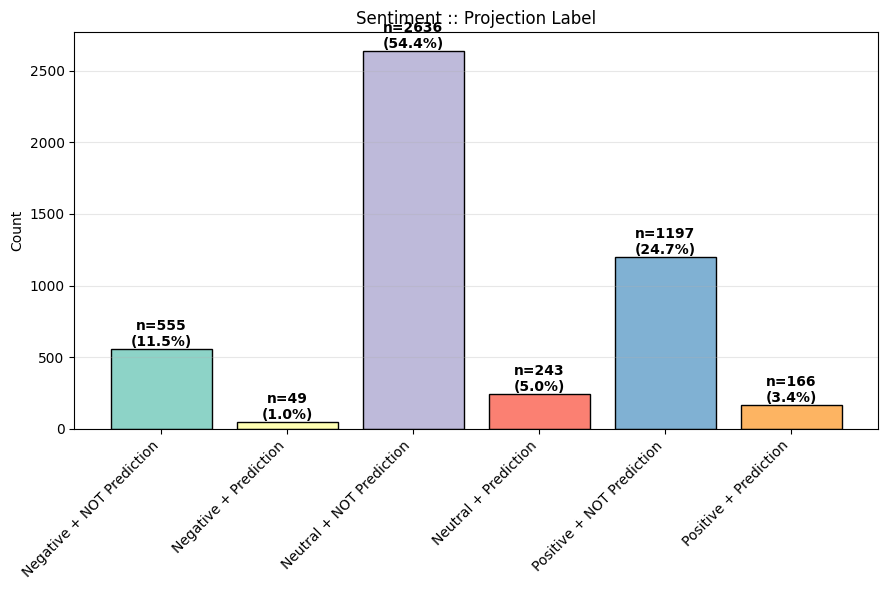

In [7]:
DataVisualizing.plot_class_distribution(
    df=maya_grouped_df,
    label_col='Class',
    title='Sentiment :: Projection Label'
    )

In [8]:
# output_file = "grouped_by_label.xlsx"
# df_sorted.to_excel(output_file, index=False)

# print("Done!")
# print(f"Grouped file saved as: {output_file}")

## My approach

In [9]:
sentiment_data_path = os.path.join(base_data_path, "financial_phrase_bank/all-data.csv")
original_df = DataProcessing.load_from_file(sentiment_data_path, encoding='latin', header=None)
original_df.rename(columns={0: 'Sentiment', 1: 'Base Sentence'}, inplace=True)
original_df

,Sentiment,Base Sentence
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


In [10]:
sentiments = original_df['Sentiment'].unique()
sentiments

array(['neutral', 'negative', 'positive'], dtype=object)


LOAD FINANCIAL PHRASEBANK DATASET
Loading from: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/financial_phrase_bank/annotators/fpb-maya-binary-imbalanced-96d-v1.csv
Loaded shape: (4846, 4)

Converting text labels to binary...


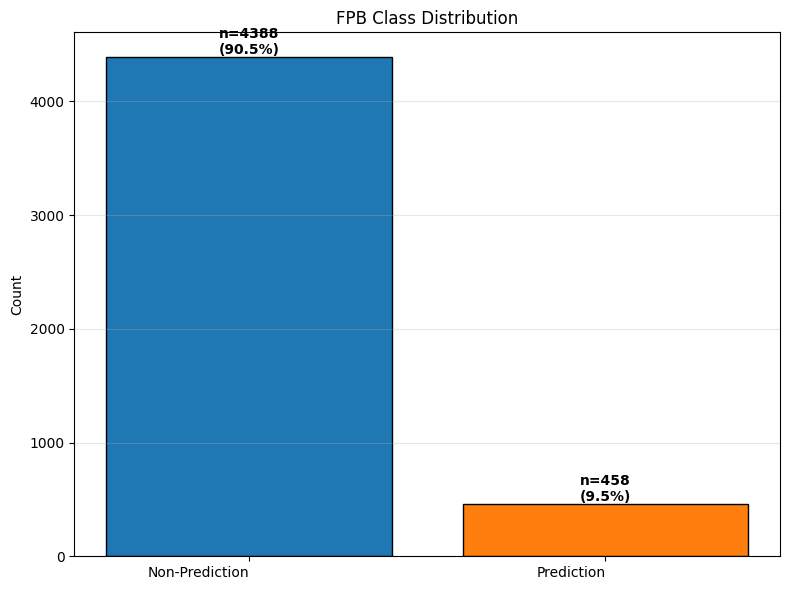

Columns: ['Base Sentence', 'Ground Truth', 'maya_label', 'Sentence Label', 'Author Type']

Ground Truth distribution:
Ground Truth
0    4388
1     458
Name: count, dtype: int64

Preview:
                                       Base Sentence  Ground Truth  \
0  With the new production plant the company woul...             1   
1  According to the company 's updated strategy f...             1   
2  TeliaSonera TLSN said the offer is in line wit...             1   

   maya_label  Sentence Label  Author Type          Dataset Name  
0  PREDICTION               1            1  financial_phrasebank  
1  PREDICTION               1            1  financial_phrasebank  
2  PREDICTION               1            1  financial_phrasebank  



,Base Sentence,Ground Truth,maya_label,Sentence Label,Dataset Name
0,With the new production plant the company woul...,1,PREDICTION,1,financial_phrasebank
1,According to the company 's updated strategy f...,1,PREDICTION,1,financial_phrasebank
2,TeliaSonera TLSN said the offer is in line wit...,1,PREDICTION,1,financial_phrasebank
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",1,PREDICTION,1,financial_phrasebank
4,The company also estimates the already carried...,1,PREDICTION,1,financial_phrasebank
...,...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,0,NON-PREDICTION,0,financial_phrasebank
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,0,NON-PREDICTION,0,financial_phrasebank
4843,Operating profit fell to EUR 35.4 mn from EUR ...,0,NON-PREDICTION,0,financial_phrasebank
4844,Net sales of the Paper segment decreased to EU...,0,NON-PREDICTION,0,financial_phrasebank


In [11]:
our_df = DataProcessing.load_financial_phrasebank_dataset(notebook_dir, predictions_only=False)
our_df.drop(columns=['Author Type'], inplace=True)
our_df

In [12]:
my_merged_df = pd.merge(original_df, our_df, left_on='Base Sentence', right_on='Base Sentence', how='left')
my_merged_df

,Sentiment,Base Sentence,Ground Truth,maya_label,Sentence Label,Dataset Name
0,neutral,"According to Gran , the company has no plans t...",0.0,NON-PREDICTION,0.0,financial_phrasebank
1,neutral,Technopolis plans to develop in stages an area...,0.0,NON-PREDICTION,0.0,financial_phrasebank
2,negative,The international electronic industry company ...,0.0,NON-PREDICTION,0.0,financial_phrasebank
3,positive,With the new production plant the company woul...,1.0,PREDICTION,1.0,financial_phrasebank
4,positive,According to the company 's updated strategy f...,1.0,PREDICTION,1.0,financial_phrasebank
...,...,...,...,...,...,...
4857,negative,LONDON MarketWatch -- Share prices ended lower...,0.0,NON-PREDICTION,0.0,financial_phrasebank
4858,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,0.0,NON-PREDICTION,0.0,financial_phrasebank
4859,negative,Operating profit fell to EUR 35.4 mn from EUR ...,0.0,NON-PREDICTION,0.0,financial_phrasebank
4860,negative,Net sales of the Paper segment decreased to EU...,0.0,NON-PREDICTION,0.0,financial_phrasebank


### Visualize

In [13]:
my_grouped_df = map_sentiment_to_prediction(my_merged_df)
my_grouped_df

,Base Sentence,Sentiment,Prediction Label,Class
0,"At this growth rate , paying off the national ...",negative,1.0,Negative + Prediction
1,"At the moment , Valio is not worried , but if ...",negative,1.0,Negative + Prediction
2,Finnish Suominen Corporation that makes wet wi...,negative,1.0,Negative + Prediction
3,As a result of the negotiations the employment...,negative,1.0,Negative + Prediction
4,Finnish software and hardware developer Elektr...,negative,1.0,Negative + Prediction
...,...,...,...,...
4772,"The apartment block will be well-located , in ...",positive,0.0,Positive + NOT Prediction
4773,"The antibody , given at repeated doses of up t...",positive,0.0,Positive + NOT Prediction
4774,Danske Bank A-S DANSKE DC jumped 3.7 percent t...,positive,0.0,Positive + NOT Prediction
4775,Our superior customer centricity and expertise...,positive,0.0,Positive + NOT Prediction


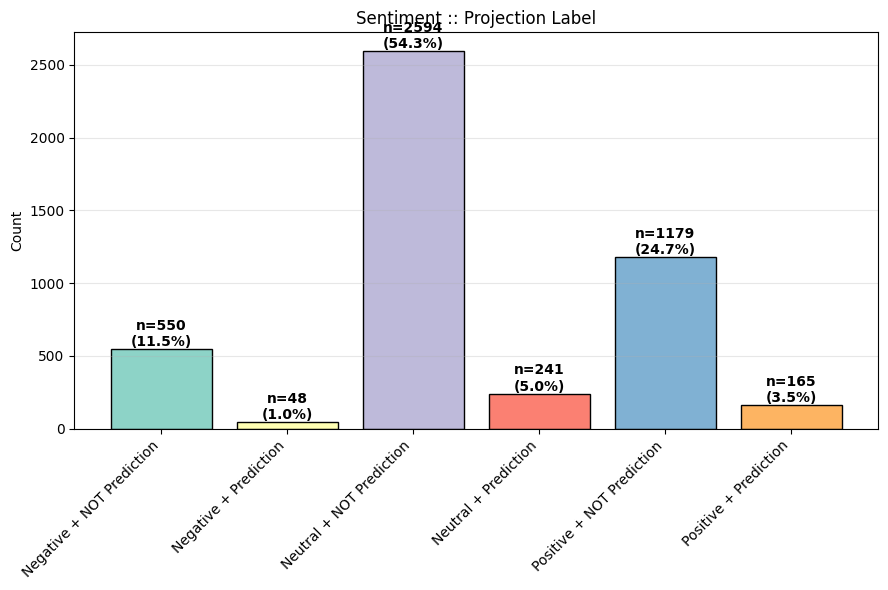

In [14]:
DataVisualizing.plot_class_distribution(
    df=my_grouped_df,
    label_col='Class',
    title='Sentiment :: Projection Label'
    )

## Compare Visualizations

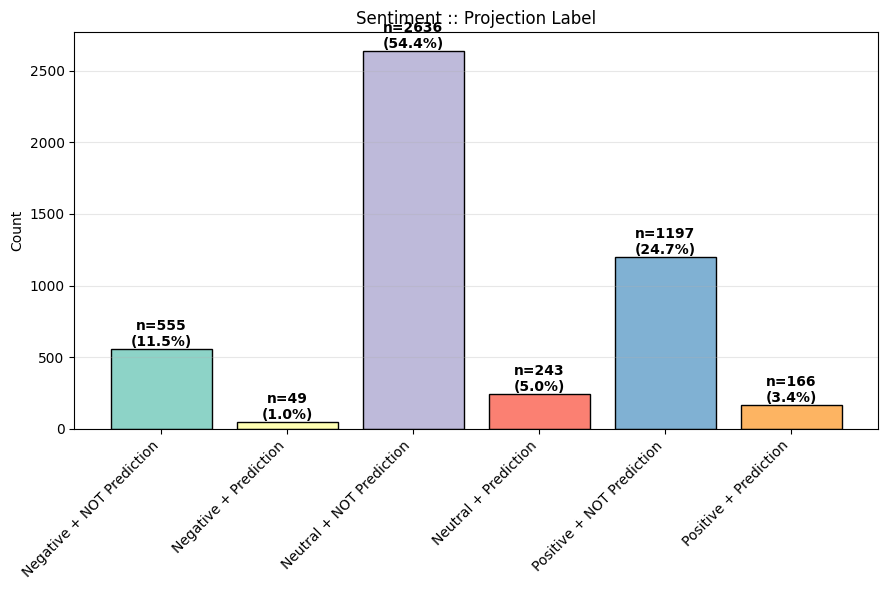

In [15]:
DataVisualizing.plot_class_distribution(
    df=maya_grouped_df,
    label_col='Class',
    title='Sentiment :: Projection Label'
    )

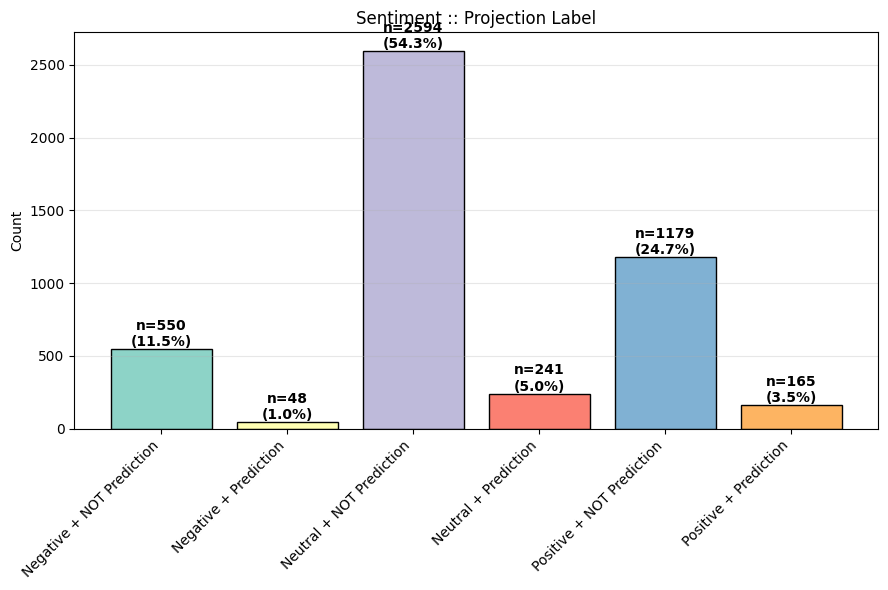

In [16]:
DataVisualizing.plot_class_distribution(
    df=my_grouped_df,
    label_col='Class',
    title='Sentiment :: Projection Label'
    )